# Exploratory Data Analysis — The Movies Dataset
COM-480 Data Visualization · Milestone 1

Sections:
1. Setup & Load
2. Univariate Distributions
3. Missing Data
4. Financial Analysis (Budget → Revenue → ROI)
5. Ratings Analysis (TMDB vs MovieLens, polarization)
6. Genre Analysis
7. Temporal Trends
8. Key Findings Memo

## 1 — Setup & Load

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
import os

warnings.filterwarnings('ignore')

# ── style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 1.2,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlepad': 10,
    'axes.labelsize': 11,
})

PALETTE = ['#6c63d5', '#f4a93d', '#e05c5c', '#3aada8', '#a4c96e', '#d98dcc']
FIGURES = '../eda/figures'
os.makedirs(FIGURES, exist_ok=True)

def savefig(name):
    plt.savefig(f'{FIGURES}/{name}.png', bbox_inches='tight', dpi=130)
    plt.show()

# ── load ───────────────────────────────────────────────────────────────────
movies = pd.read_csv('../data/processed/movies.csv')

import ast
for col in ['genres_list', 'top_cast', 'countries_list', 'companies_list', 'languages_list']:
    movies[col] = movies[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

movies_financial = movies[movies['budget'].notna() & movies['revenue'].notna()].copy()
if 'roi' not in movies_financial.columns:
    movies_financial['roi'] = movies_financial['revenue'] / movies_financial['budget']

print(f'movies          : {movies.shape}')
print(f'movies_financial: {movies_financial.shape}')
movies.dtypes

movies          : (45697, 25)
movies_financial: (5417, 26)


budget                  float64
id                        int64
original_language           str
popularity              float64
release_date                str
revenue                 float64
runtime                 float64
title                       str
vote_average            float64
vote_count              float64
year                    float64
decade                  float64
genres_list              object
countries_list           object
companies_list           object
languages_list           object
director                    str
top_cast                 object
movielens_avg_rating    float64
movielens_vote_count    float64
rating_min              float64
rating_median           float64
rating_max              float64
rating_std              float64
ratings_list                str
dtype: object

## 2 — Univariate Distributions
Understand the shape of key numeric columns before doing anything relational.

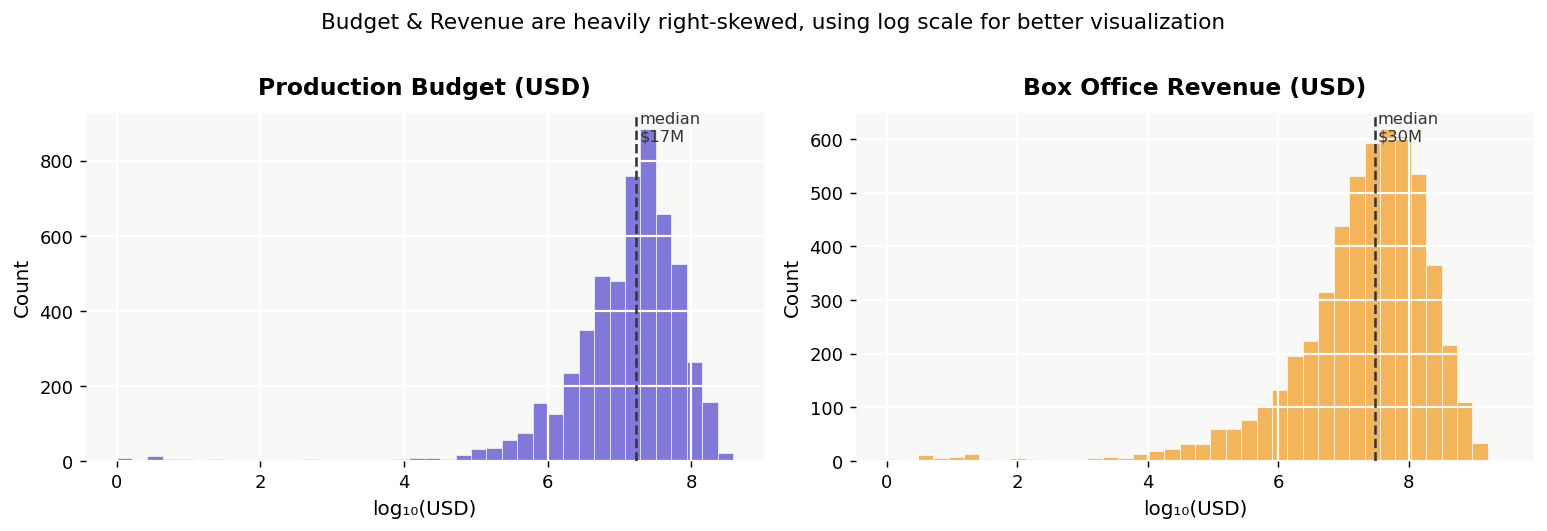

In [123]:
# ── 2a. Budget & Revenue (log scale) ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color, label in zip(
    axes,
    ['budget', 'revenue'],
    [PALETTE[0], PALETTE[1]],
    ['Production Budget (USD)', 'Box Office Revenue (USD)']
):
    data = movies_financial[col].dropna()
    data_log = np.log10(data[data > 0])
    ax.hist(data_log, bins=40, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.set_xlabel('log₁₀(USD)')
    ax.set_ylabel('Count')
    ax.set_title(label)
    median_val = data.median()
    ax.axvline(np.log10(median_val), color='#333', linewidth=1.4, linestyle='--')
    ax.text(np.log10(median_val) + 0.05, ax.get_ylim()[1] * 0.92,
            f'median\n${median_val/1e6:.0f}M', fontsize=9, color='#333')

fig.suptitle('Budget & Revenue are heavily right-skewed, using log scale for better visualization', fontsize=12, y=1.01)
plt.tight_layout()
savefig('01_budget_revenue_distribution')

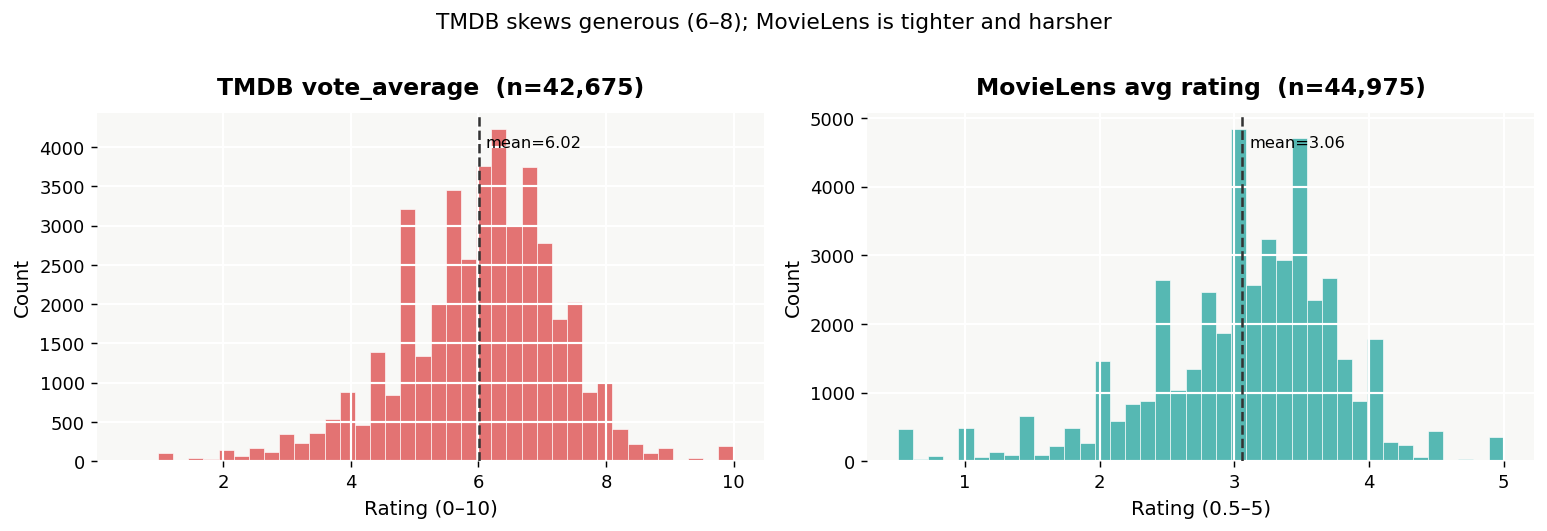

In [124]:
# ── 2b. Ratings distributions ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# TMDB vote_average
ax = axes[0]
data = movies['vote_average'].dropna()
data = data[data > 0]  # filter unrated
ax.hist(data, bins=40, color=PALETTE[2], alpha=0.85, edgecolor='white', linewidth=0.4)
ax.axvline(data.mean(), color='#333', linewidth=1.4, linestyle='--')
ax.set_xlabel('Rating (0–10)')
ax.set_ylabel('Count')
ax.set_title(f'TMDB vote_average  (n={len(data):,})')
ax.text(data.mean() + 0.1, ax.get_ylim()[1] * 0.9, f'mean={data.mean():.2f}', fontsize=9)

# MovieLens avg rating
ax = axes[1]
data2 = movies['movielens_avg_rating'].dropna()
ax.hist(data2, bins=40, color=PALETTE[3], alpha=0.85, edgecolor='white', linewidth=0.4)
ax.axvline(data2.mean(), color='#333', linewidth=1.4, linestyle='--')
ax.set_xlabel('Rating (0.5–5)')
ax.set_ylabel('Count')
ax.set_title(f'MovieLens avg rating  (n={len(data2):,})')
ax.text(data2.mean() + 0.05, ax.get_ylim()[1] * 0.9, f'mean={data2.mean():.2f}', fontsize=9)

fig.suptitle('TMDB skews generous (6–8); MovieLens is tighter and harsher', fontsize=12, y=1.01)
plt.tight_layout()
savefig('02_rating_distributions')

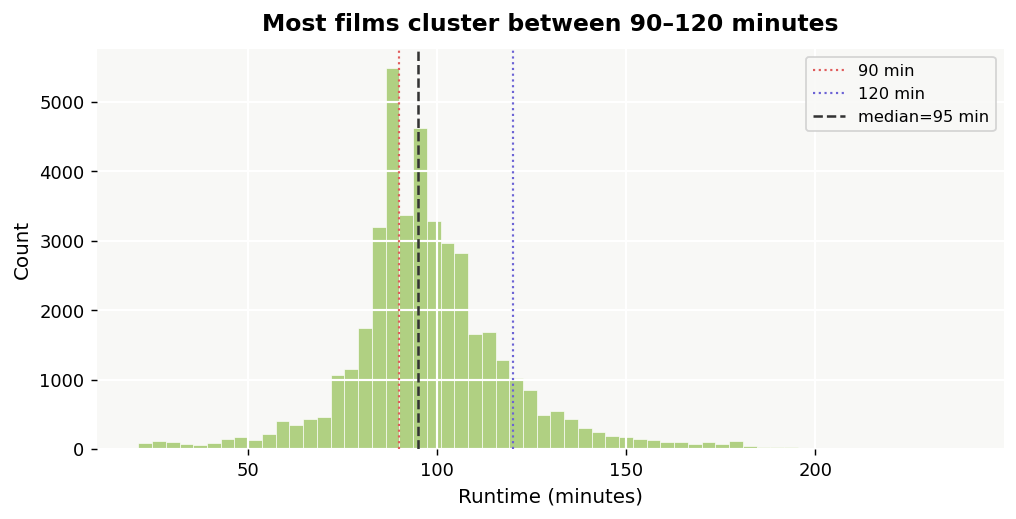

In [125]:
# ── 2c. Runtime distribution ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
data = movies['runtime'].dropna()
data = data[(data > 20) & (data < 240)]  # reasonable range
ax.hist(data, bins=60, color=PALETTE[4], alpha=0.85, edgecolor='white', linewidth=0.4)
ax.axvline(90, color=PALETTE[2], linewidth=1.2, linestyle=':', label='90 min')
ax.axvline(120, color=PALETTE[0], linewidth=1.2, linestyle=':', label='120 min')
ax.axvline(data.median(), color='#333', linewidth=1.4, linestyle='--', label=f'median={data.median():.0f} min')
ax.set_xlabel('Runtime (minutes)')
ax.set_ylabel('Count')
ax.set_title('Most films cluster between 90–120 minutes')
ax.legend(fontsize=9)
savefig('03_runtime_distribution')

## 3 — Missing Data Map

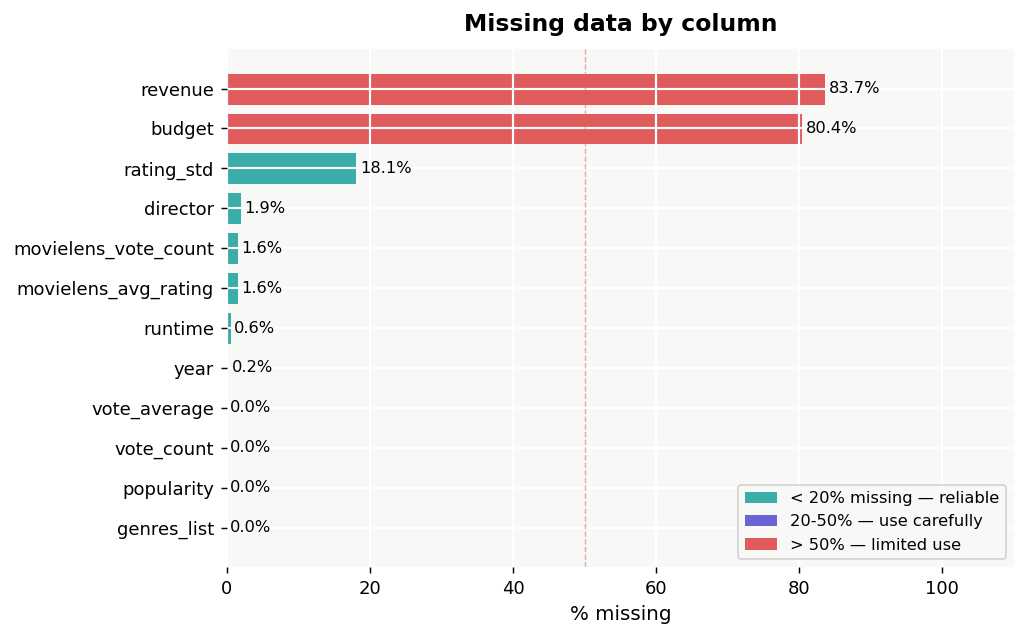

In [126]:
key_cols = [
    'budget', 'revenue', 'runtime', 'popularity',
    'vote_average', 'vote_count', 'year',
    'director', 'genres_list',
    'movielens_avg_rating', 'movielens_vote_count',
    'rating_std'
]

missing_pct = (
    movies[key_cols]
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [PALETTE[2] if v > 50 else PALETTE[0] if v > 20 else PALETTE[3] for v in missing_pct]
bars = ax.barh(missing_pct.index, missing_pct.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('% missing')
ax.set_title('Missing data by column')
ax.axvline(50, color=PALETTE[2], linewidth=0.8, linestyle='--', alpha=0.5)
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlim(0, 110)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE[3], label='< 20% missing — reliable'),
    Patch(facecolor=PALETTE[0], label='20-50% — use carefully'),
    Patch(facecolor=PALETTE[2], label='> 50% — limited use'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
savefig('04_missing_data')

## 4 — Financial Analysis

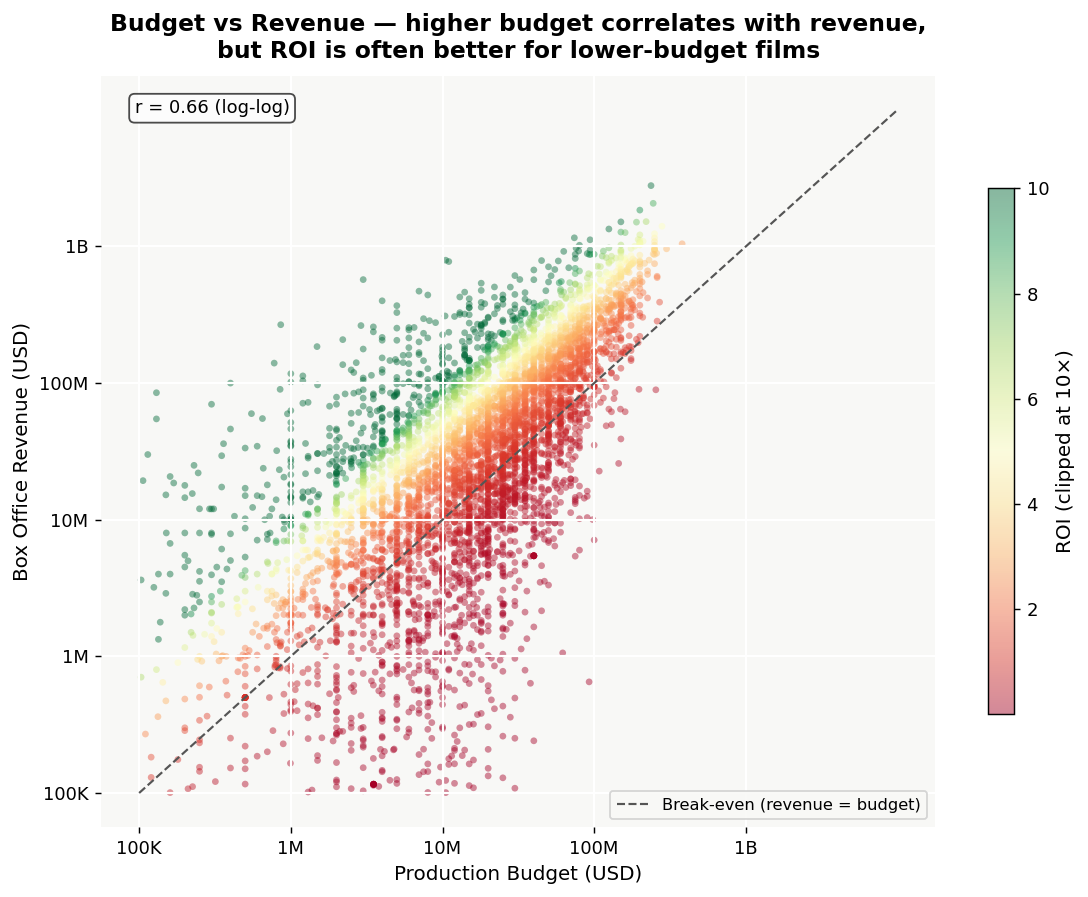

In [127]:
# ── 4a. Budget vs Revenue scatter (log-log) ───────────────────────────────
df = movies_financial[
    (movies_financial['budget'] > 1e5) &
    (movies_financial['revenue'] > 1e5)
].copy()

fig, ax = plt.subplots(figsize=(9, 7))

# Color by ROI
roi_clip = df['roi'].clip(0, 10)
sc = ax.scatter(
    np.log10(df['budget']),
    np.log10(df['revenue']),
    c=roi_clip,
    cmap='RdYlGn',
    alpha=0.45,
    s=14,
    linewidths=0
)
plt.colorbar(sc, ax=ax, label='ROI (clipped at 10×)', shrink=0.7)

# Break-even line (revenue = budget)
lims = [5, 10]
ax.plot(lims, lims, color='#555', linewidth=1.2, linestyle='--', label='Break-even (revenue = budget)')

# Pearson r
r = np.corrcoef(np.log10(df['budget']), np.log10(df['revenue']))[0, 1]
ax.text(0.04, 0.95, f'r = {r:.2f} (log-log)', transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Axis labels with real-world ticks
tick_vals = [1e5, 1e6, 1e7, 1e8, 1e9]
tick_labels = ['100K', '1M', '10M', '100M', '1B']
ax.set_xticks(np.log10(tick_vals)); ax.set_xticklabels(tick_labels)
ax.set_yticks(np.log10(tick_vals)); ax.set_yticklabels(tick_labels)
ax.set_xlabel('Production Budget (USD)')
ax.set_ylabel('Box Office Revenue (USD)')
ax.set_title('Budget vs Revenue — higher budget correlates with revenue,\nbut ROI is often better for lower-budget films')
ax.legend(fontsize=9)
plt.tight_layout()
savefig('05_budget_vs_revenue')

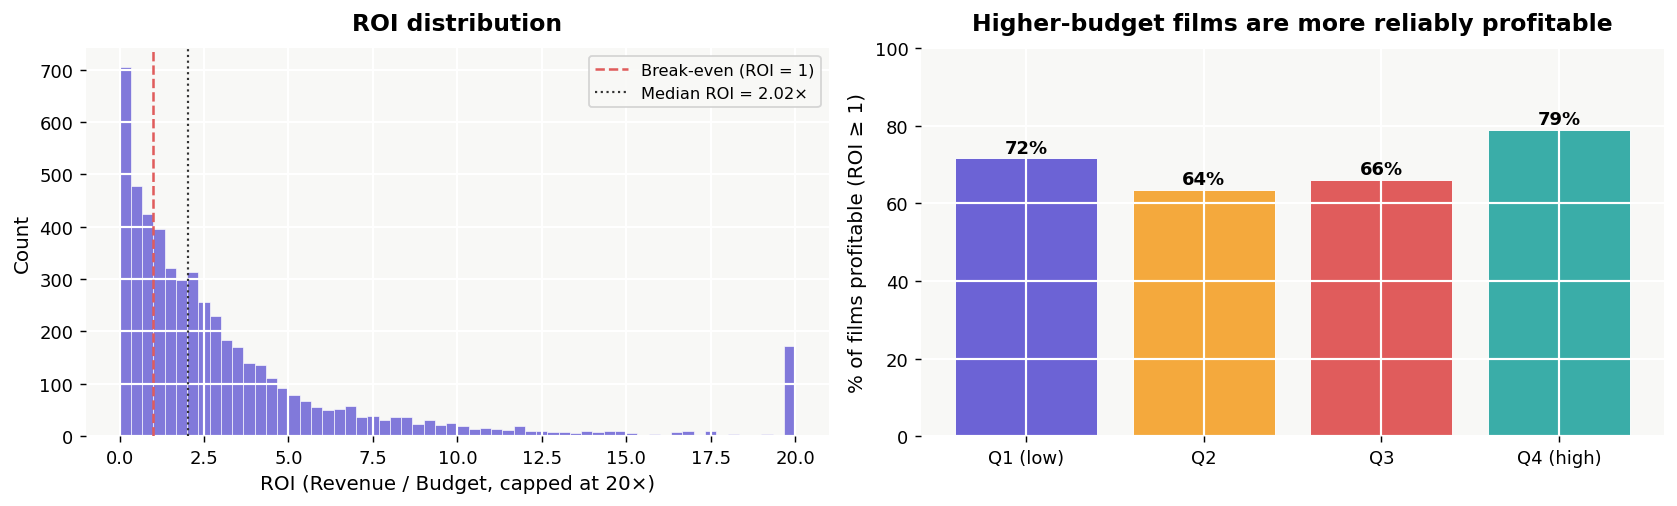

In [128]:
# ── 4b. ROI distribution (capped) ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution
ax = axes[0]
roi_data = movies_financial['roi'][
    (movies_financial['roi'] > 0) &
    (movies_financial['budget'] > 1e5)
].clip(0, 20)
ax.hist(roi_data, bins=60, color=PALETTE[0], alpha=0.85, edgecolor='white', linewidth=0.4)
ax.axvline(1, color=PALETTE[2], linewidth=1.4, linestyle='--', label='Break-even (ROI = 1)')
ax.axvline(roi_data.median(), color='#333', linewidth=1.2, linestyle=':', label=f'Median ROI = {roi_data.median():.2f}×')
ax.set_xlabel('ROI (Revenue / Budget, capped at 20×)')
ax.set_ylabel('Count')
ax.set_title('ROI distribution')
ax.legend(fontsize=9)

# % profitable by budget quartile
ax = axes[1]
df2 = movies_financial[
    (movies_financial['budget'] > 1e5) &
    movies_financial['roi'].notna()
].copy()
df2['budget_quartile'] = pd.qcut(df2['budget'], 4,
    labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
profit_rate = df2.groupby('budget_quartile', observed=True)['roi'].apply(
    lambda x: (x >= 1).mean() * 100
)
bars = ax.bar(profit_rate.index, profit_rate.values,
              color=PALETTE[:4], edgecolor='white', linewidth=0.5)
ax.set_ylabel('% of films profitable (ROI ≥ 1)')
ax.set_title('Higher-budget films are more reliably profitable')
ax.set_ylim(0, 100)
for bar, val in zip(bars, profit_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5,
            f'{val:.0f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
savefig('06_roi_analysis')

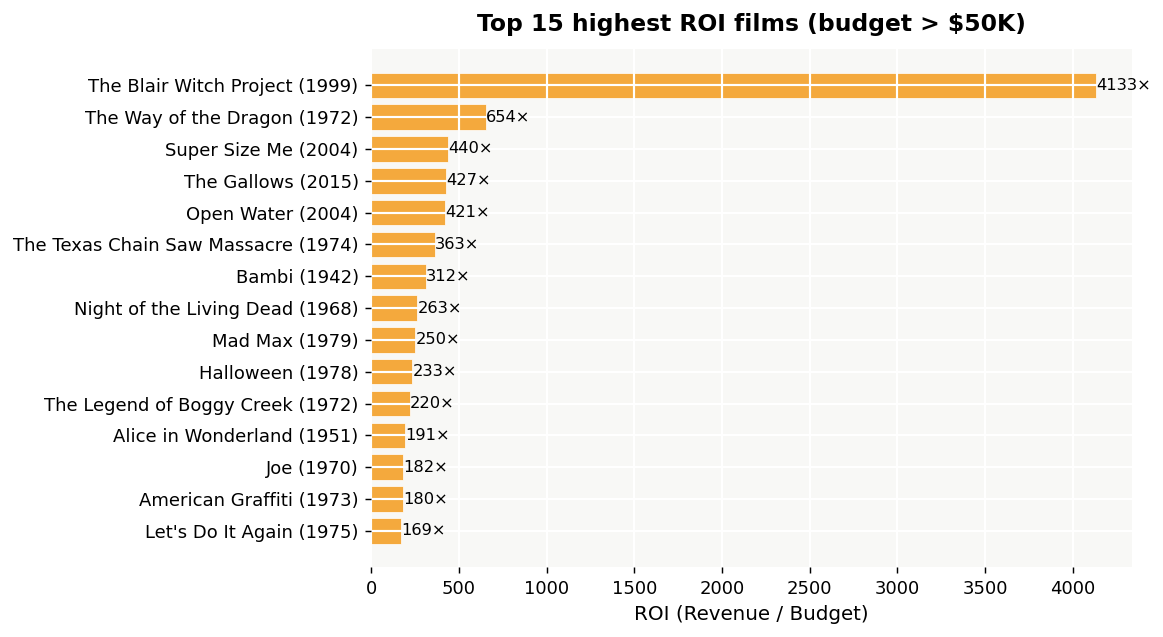

In [129]:
# ── 4c. Top 15 highest ROI films ──────────────────────────────────────────
top_roi = (
    movies_financial[
        (movies_financial['budget'] > 5e4) &  # exclude micro-budget noise
        movies_financial['roi'].notna() &
        movies_financial['title'].notna()
    ]
    .nlargest(15, 'roi')[['title', 'year', 'budget', 'revenue', 'roi']]
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_roi['title'] + ' (' + top_roi['year'].astype('Int64').astype(str) + ')',
               top_roi['roi'], color=PALETTE[1], edgecolor='white', linewidth=0.4)
ax.set_xlabel('ROI (Revenue / Budget)')
ax.set_title('Top 15 highest ROI films (budget > $50K)')
ax.invert_yaxis()
for bar, val in zip(bars, top_roi['roi'].values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}×', va='center', fontsize=9)
plt.tight_layout()
savefig('07_top_roi_films')

## 5 — Ratings Analysis

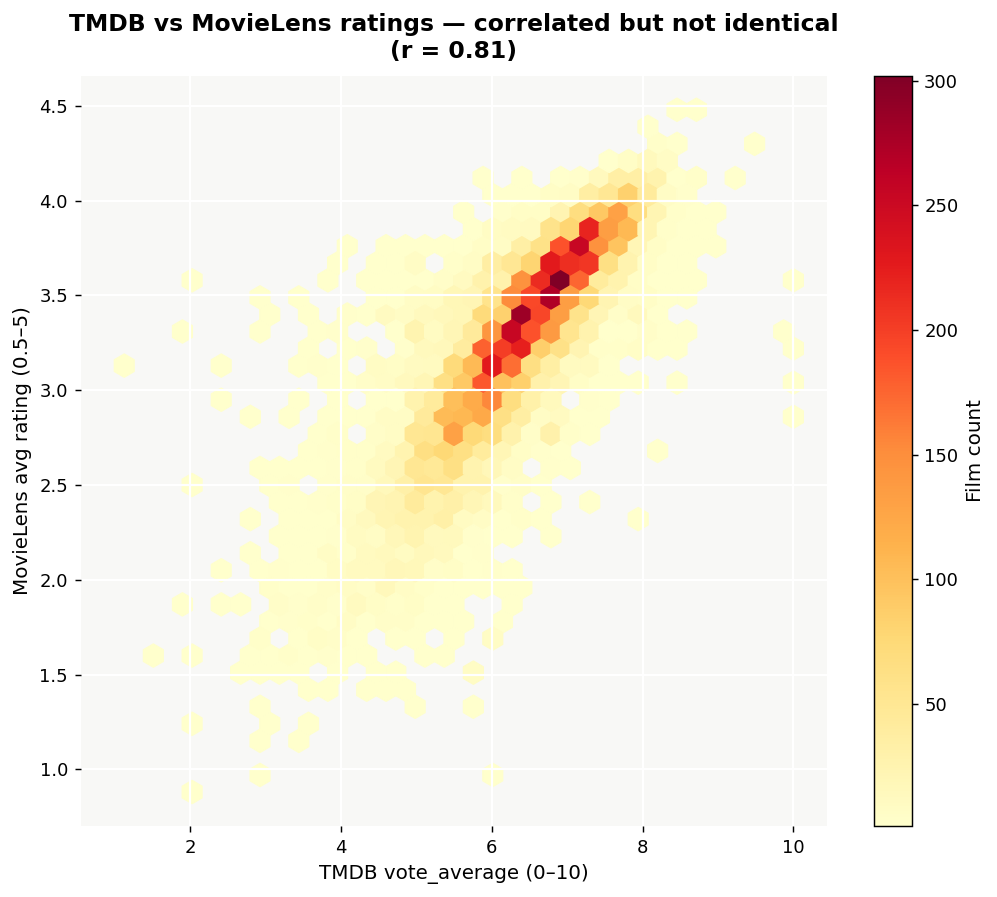

In [130]:
# ── 5a. TMDB vs MovieLens agreement ──────────────────────────────────────
df_r = movies[
    movies['vote_average'].notna() &
    movies['movielens_avg_rating'].notna() &
    (movies['vote_average'] > 0) &
    (movies['movielens_vote_count'] >= 50)  # enough ML votes to be meaningful
].copy()

# Normalise both to 0-1
df_r['tmdb_norm']  = df_r['vote_average'] / 10
df_r['ml_norm']    = (df_r['movielens_avg_rating'] - 0.5) / 4.5
df_r['agreement']  = 1 - (df_r['tmdb_norm'] - df_r['ml_norm']).abs()

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.hexbin(df_r['vote_average'], df_r['movielens_avg_rating'],
               gridsize=35, cmap='YlOrRd', mincnt=1)
plt.colorbar(sc, ax=ax, label='Film count')
r = df_r[['vote_average', 'movielens_avg_rating']].corr().iloc[0, 1]
ax.set_xlabel('TMDB vote_average (0–10)')
ax.set_ylabel('MovieLens avg rating (0.5–5)')
ax.set_title(f'TMDB vs MovieLens ratings — correlated but not identical\n(r = {r:.2f})')
plt.tight_layout()
savefig('08_tmdb_vs_movielens')

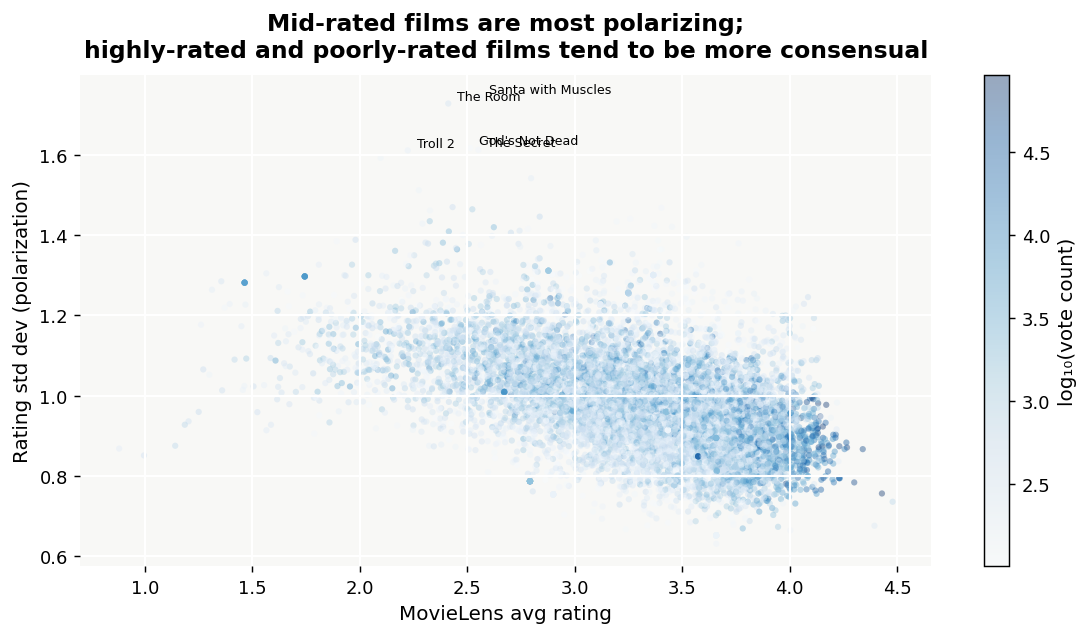

In [131]:
# ── 5b. Polarization (rating_std) vs popularity ───────────────────────────
df_p = movies[
    movies['rating_std'].notna() &
    movies['movielens_vote_count'].notna() &
    (movies['movielens_vote_count'] >= 100)
].copy()

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    df_p['movielens_avg_rating'],
    df_p['rating_std'],
    c=np.log10(df_p['movielens_vote_count'] + 1),
    cmap='Blues',
    alpha=0.4, s=12, linewidths=0
)
plt.colorbar(sc, ax=ax, label='log₁₀(vote count)')
ax.set_xlabel('MovieLens avg rating')
ax.set_ylabel('Rating std dev (polarization)')
ax.set_title('Mid-rated films are most polarizing;\nhighly-rated and poorly-rated films tend to be more consensual')

# Annotate most polarizing films
top_polar = df_p.nlargest(5, 'rating_std')
for _, row in top_polar.iterrows():
    ax.annotate(row['title'], (row['movielens_avg_rating'], row['rating_std']),
                fontsize=7, xytext=(5, 2), textcoords='offset points')
plt.tight_layout()
savefig('09_polarization')

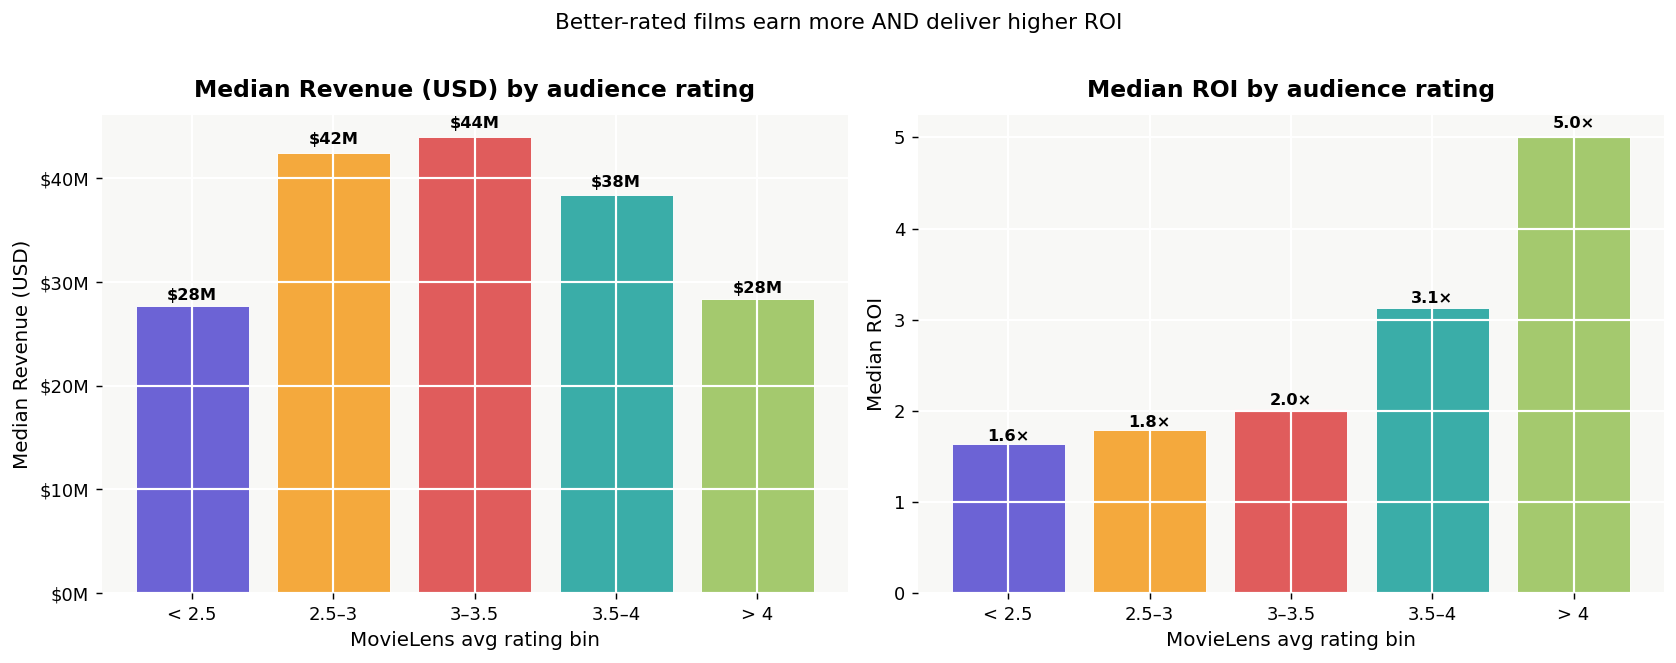

In [132]:
# ── 5c. Does critical acclaim drive box office? ───────────────────────────
df_cr = movies_financial[
    movies_financial['movielens_avg_rating'].notna() &
    (movies_financial['movielens_vote_count'] >= 50) &
    (movies_financial['revenue'] > 1e5)
].copy()

# Bin ratings
df_cr['rating_bin'] = pd.cut(df_cr['movielens_avg_rating'],
    bins=[0, 2.5, 3.0, 3.5, 4.0, 5.1],
    labels=['< 2.5', '2.5–3', '3–3.5', '3.5–4', '> 4'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, label, fmt in zip(
    axes,
    ['revenue', 'roi'],
    ['Median Revenue (USD)', 'Median ROI'],
    ['${:.0f}M', '{:.1f}×']
):
    grouped = df_cr.groupby('rating_bin', observed=True)[metric].median()
    bars = ax.bar(grouped.index, grouped.values,
                  color=PALETTE[:len(grouped)], edgecolor='white', linewidth=0.5)
    ax.set_xlabel('MovieLens avg rating bin')
    ax.set_ylabel(label)
    if metric == 'revenue':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
    ax.set_title(f'{label} by audience rating')
    for bar, val in zip(bars, grouped.values):
        disp = f'${val/1e6:.0f}M' if metric == 'revenue' else f'{val:.1f}×'
        ax.text(bar.get_x() + bar.get_width()/2, val * 1.02,
                disp, ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Better-rated films earn more AND deliver higher ROI', fontsize=12, y=1.01)
plt.tight_layout()
savefig('10_rating_vs_box_office')

## 6 — Genre Analysis

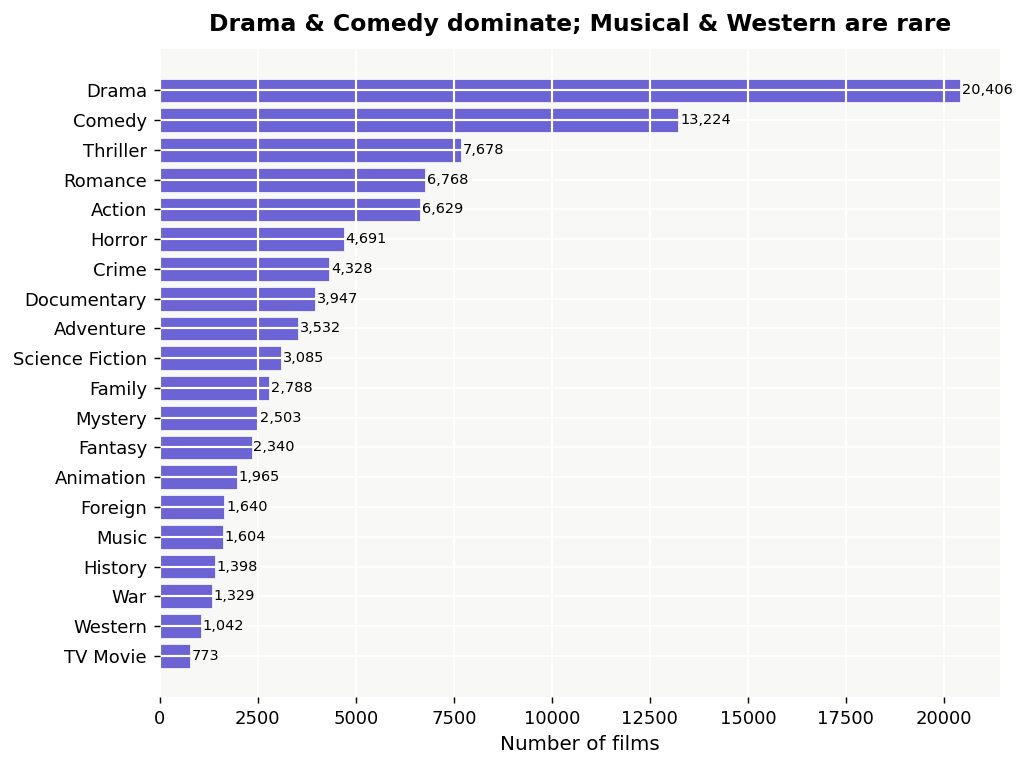

In [133]:
# ── 6a. Genre frequency ───────────────────────────────────────────────────
genre_counts = Counter(g for genres in movies['genres_list'] for g in genres)
genre_df = pd.DataFrame(genre_counts.items(), columns=['genre', 'count']).sort_values('count', ascending=True)
genre_df = genre_df[genre_df['count'] > 50]  # drop noise

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(genre_df['genre'], genre_df['count'],
        color=PALETTE[0], edgecolor='white', linewidth=0.4)
ax.set_xlabel('Number of films')
ax.set_title('Drama & Comedy dominate; Musical & Western are rare')
for i, (val, label) in enumerate(zip(genre_df['count'], genre_df['genre'])):
    ax.text(val + 50, i, f'{val:,}', va='center', fontsize=8)
plt.tight_layout()
savefig('11_genre_frequency')

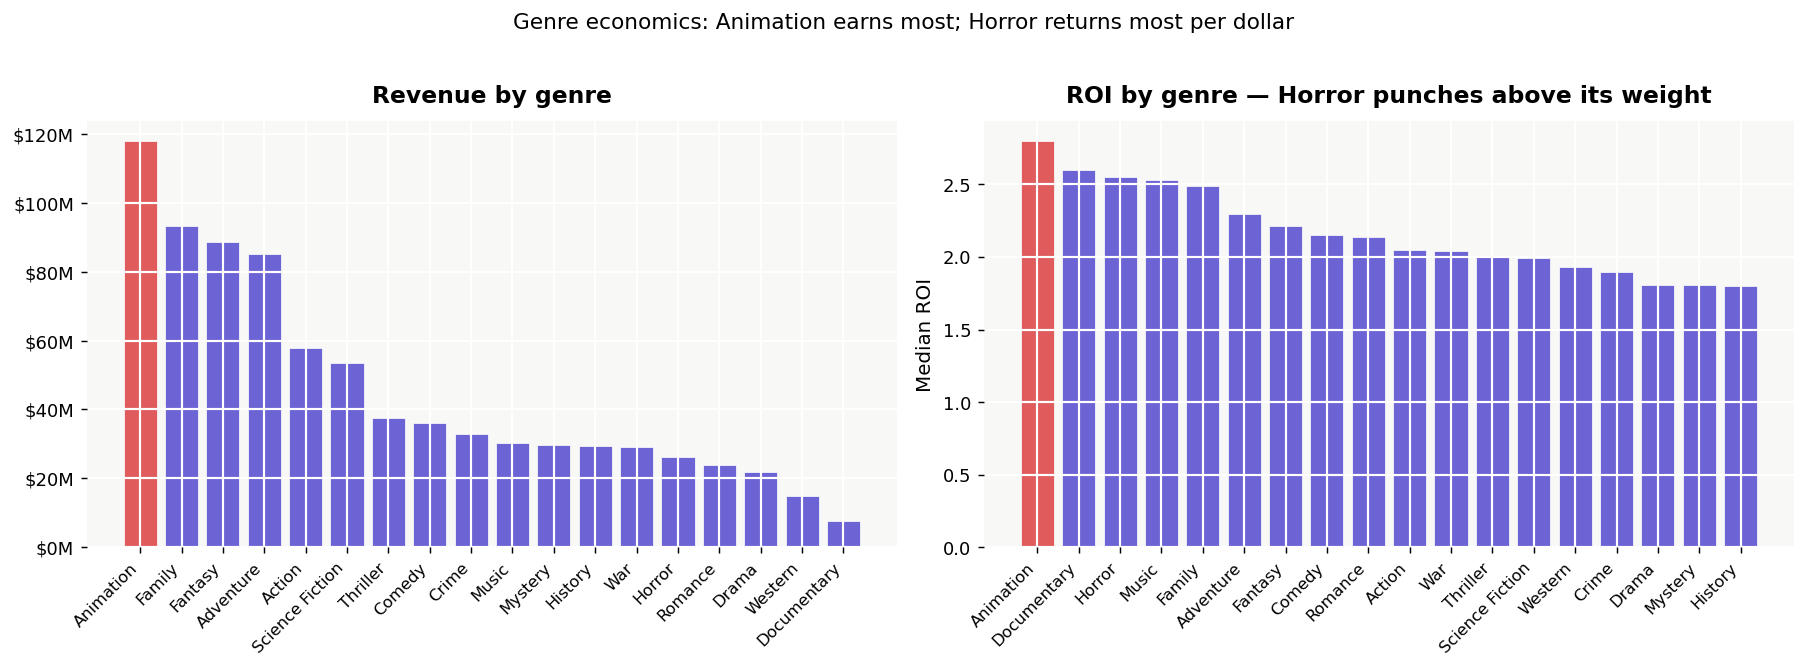

In [134]:
# ── 6b. Genre median revenue & ROI ───────────────────────────────────────
exploded = movies_financial[
    (movies_financial['budget'] > 1e5) &
    (movies_financial['revenue'] > 1e5)
].explode('genres_list').rename(columns={'genres_list': 'genre'})

genre_fin = (
    exploded
    .groupby('genre')
    .agg(
        n=('revenue', 'count'),
        median_revenue=('revenue', 'median'),
        median_roi=('roi', 'median')
    )
    .query('n >= 30')  # min 30 films per genre
    .sort_values('median_revenue', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, ylabel, title in zip(
    axes,
    ['median_revenue', 'median_roi'],
    ['Median Revenue (USD)', 'Median ROI'],
    ['Revenue by genre', 'ROI by genre — Horror punches above its weight']
):
    data = genre_fin[col].sort_values(ascending=False)
    colors = [PALETTE[2] if v == data.max() else PALETTE[0] for v in data.values]
    bars = ax.bar(data.index, data.values, color=colors, edgecolor='white', linewidth=0.4)
    ax.set_xticklabels(data.index, rotation=45, ha='right', fontsize=9)
    ax.set_title(title)
    if col == 'median_revenue':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
    else:
        ax.set_ylabel('Median ROI')

plt.suptitle('Genre economics: Animation earns most; Horror returns most per dollar', fontsize=12, y=1.02)
plt.tight_layout()
savefig('12_genre_financials')

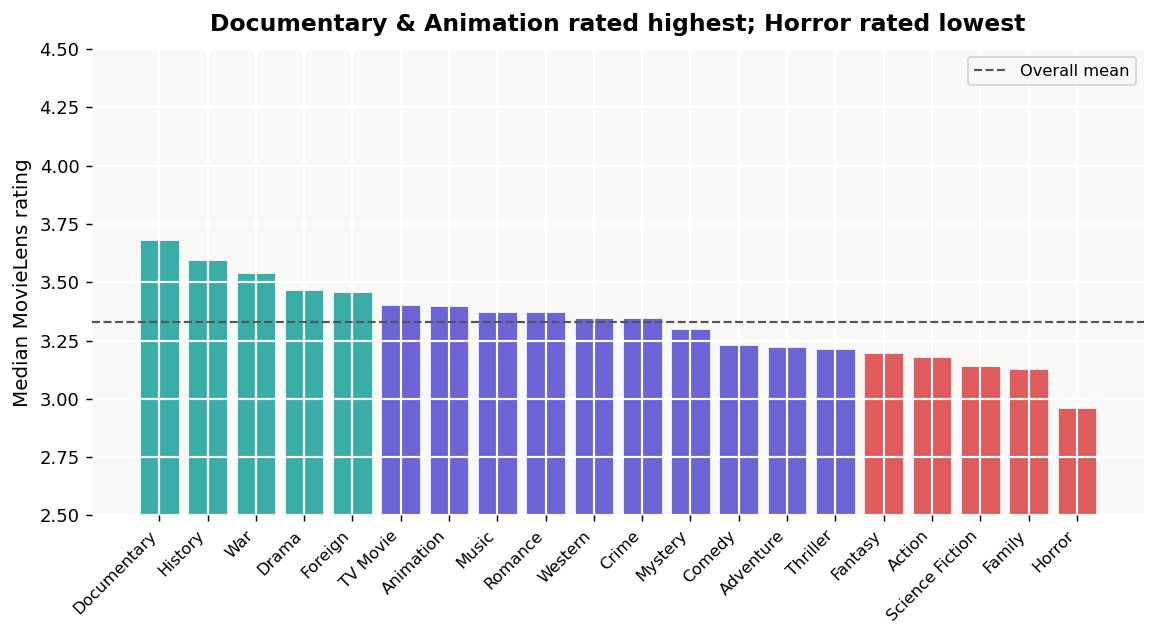

In [135]:
# ── 6c. Genre median RATING ───────────────────────────────────────────────
exploded_r = movies[
    movies['movielens_avg_rating'].notna() &
    (movies['movielens_vote_count'] >= 50)
].explode('genres_list').rename(columns={'genres_list': 'genre'})

genre_ratings = (
    exploded_r
    .groupby('genre')
    .agg(n=('movielens_avg_rating', 'count'),
         median_rating=('movielens_avg_rating', 'median'))
    .query('n >= 30')
    .sort_values('median_rating', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [PALETTE[3] if v >= genre_ratings['median_rating'].quantile(0.75)
          else PALETTE[2] if v <= genre_ratings['median_rating'].quantile(0.25)
          else PALETTE[0] for v in genre_ratings['median_rating'].values]
ax.bar(genre_ratings.index, genre_ratings['median_rating'],
       color=colors, edgecolor='white', linewidth=0.4)
ax.axhline(genre_ratings['median_rating'].mean(), color='#555',
           linewidth=1.2, linestyle='--', label='Overall mean')
ax.set_xticklabels(genre_ratings.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Median MovieLens rating')
ax.set_title('Documentary & Animation rated highest; Horror rated lowest')
ax.set_ylim(2.5, 4.5)
ax.legend(fontsize=9)
plt.tight_layout()
savefig('13_genre_ratings')

## 7 — Temporal Trends

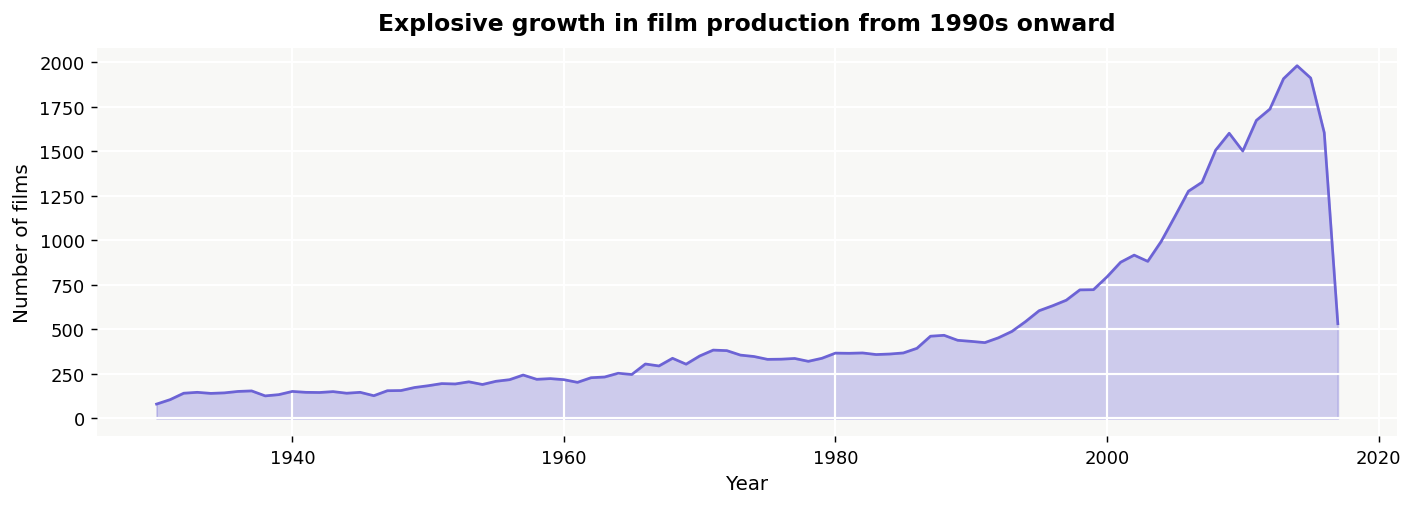

In [136]:
# ── 7a. Film production volume over time ──────────────────────────────────
year_counts = (
    movies[movies['year'].between(1930, 2017)]
    .groupby('year')
    .size()
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(year_counts.index, year_counts.values,
                alpha=0.3, color=PALETTE[0])
ax.plot(year_counts.index, year_counts.values,
        color=PALETTE[0], linewidth=1.5)
ax.set_xlabel('Year')
ax.set_ylabel('Number of films')
ax.set_title('Explosive growth in film production from 1990s onward')
plt.tight_layout()
savefig('14_production_over_time')

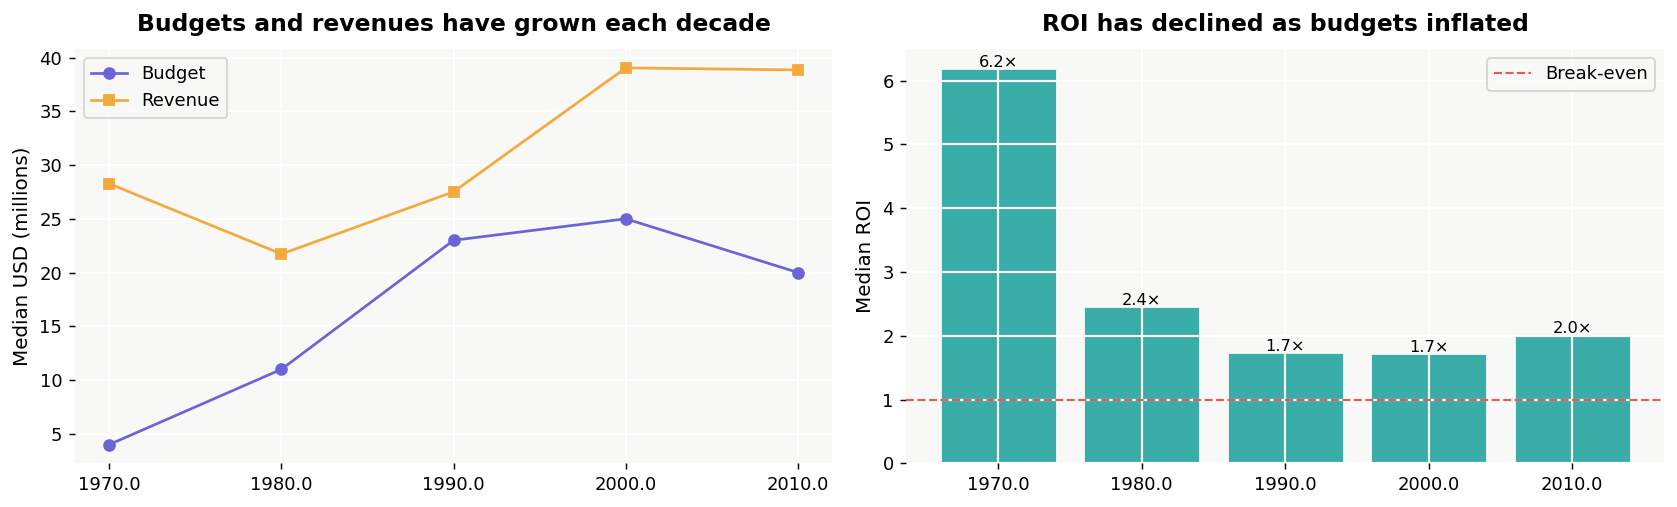

In [137]:
# ── 7b. Budget inflation by decade ────────────────────────────────────────
decade_fin = (
    movies_financial[
        movies_financial['decade'].between(1970, 2010) &
        (movies_financial['budget'] > 1e5)
    ]
    .groupby('decade')
    .agg(
        median_budget=('budget', 'median'),
        median_revenue=('revenue', 'median'),
        median_roi=('roi', 'median'),
        n=('budget', 'count')
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
x = decade_fin['decade'].astype(str)
ax.plot(x, decade_fin['median_budget'] / 1e6,  'o-', color=PALETTE[0], label='Budget')
ax.plot(x, decade_fin['median_revenue'] / 1e6, 's-', color=PALETTE[1], label='Revenue')
ax.set_ylabel('Median USD (millions)')
ax.set_title('Budgets and revenues have grown each decade')
ax.legend()

ax = axes[1]
bars = ax.bar(x, decade_fin['median_roi'],
              color=PALETTE[3], edgecolor='white', linewidth=0.4)
ax.axhline(1, color=PALETTE[2], linewidth=1.2, linestyle='--', label='Break-even')
ax.set_ylabel('Median ROI')
ax.set_title('ROI has declined as budgets inflated')
ax.legend()
for bar, val in zip(bars, decade_fin['median_roi'].values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.03,
            f'{val:.1f}×', ha='center', fontsize=9)

plt.tight_layout()
savefig('15_decade_financials')

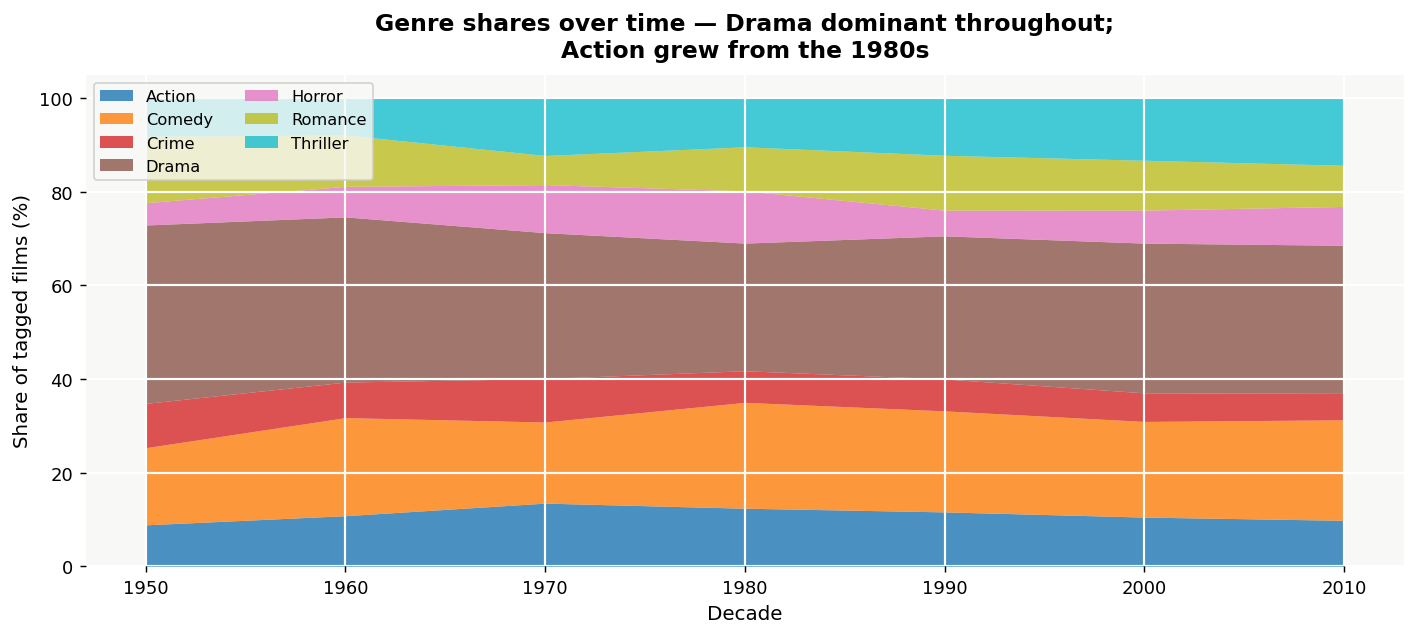

In [138]:
# ── 7c. Genre share over decades (top 7 genres) ───────────────────────────
TOP_GENRES = [
    g for g, _ in Counter(
        g for gs in movies['genres_list'] for g in gs
    ).most_common(7)
]

df_gd = (
    movies[movies['decade'].between(1950, 2010)]
    .explode('genres_list')
    .rename(columns={'genres_list': 'genre'})
    .query('genre in @TOP_GENRES')
    .groupby(['decade', 'genre'])
    .size()
    .reset_index(name='count')
)

# Normalise to share per decade
decade_totals = df_gd.groupby('decade')['count'].transform('sum')
df_gd['share'] = df_gd['count'] / decade_totals * 100

pivot = df_gd.pivot(index='decade', columns='genre', values='share').fillna(0)

fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot(kind='area', stacked=True, ax=ax, colormap='tab10', alpha=0.8, linewidth=0)
ax.set_xlabel('Decade')
ax.set_ylabel('Share of tagged films (%)')
ax.set_title('Genre shares over time — Drama dominant throughout;\nAction grew from the 1980s')
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
savefig('16_genre_over_time')

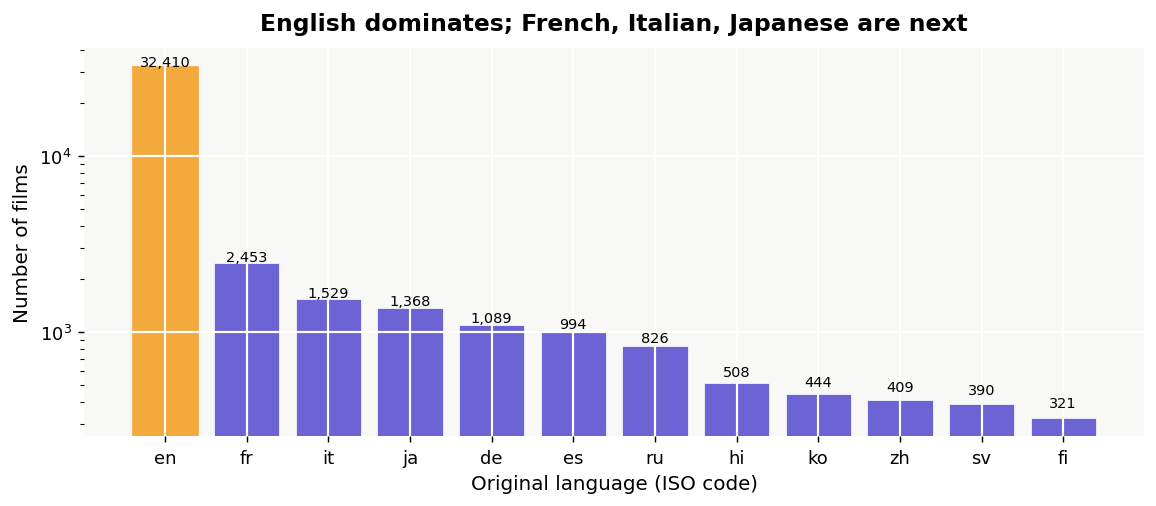

In [139]:
# ── 7d. Language breakdown ────────────────────────────────────────────────
lang_counts = (
    movies['original_language']
    .value_counts()
    .head(12)
)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(lang_counts.index, lang_counts.values,
              color=PALETTE[0], edgecolor='white', linewidth=0.4)
ax.set_yscale('log')
bars[0].set_color(PALETTE[1])  # highlight English
ax.set_xlabel('Original language (ISO code)')
ax.set_ylabel('Number of films')
ax.set_title('English dominates; French, Italian, Japanese are next')
for bar, val in zip(bars, lang_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 50,
            f'{val:,}', ha='center', fontsize=8)
plt.tight_layout()
savefig('17_language_breakdown')

## 8 — Correlation Heatmap & Key Findings Memo

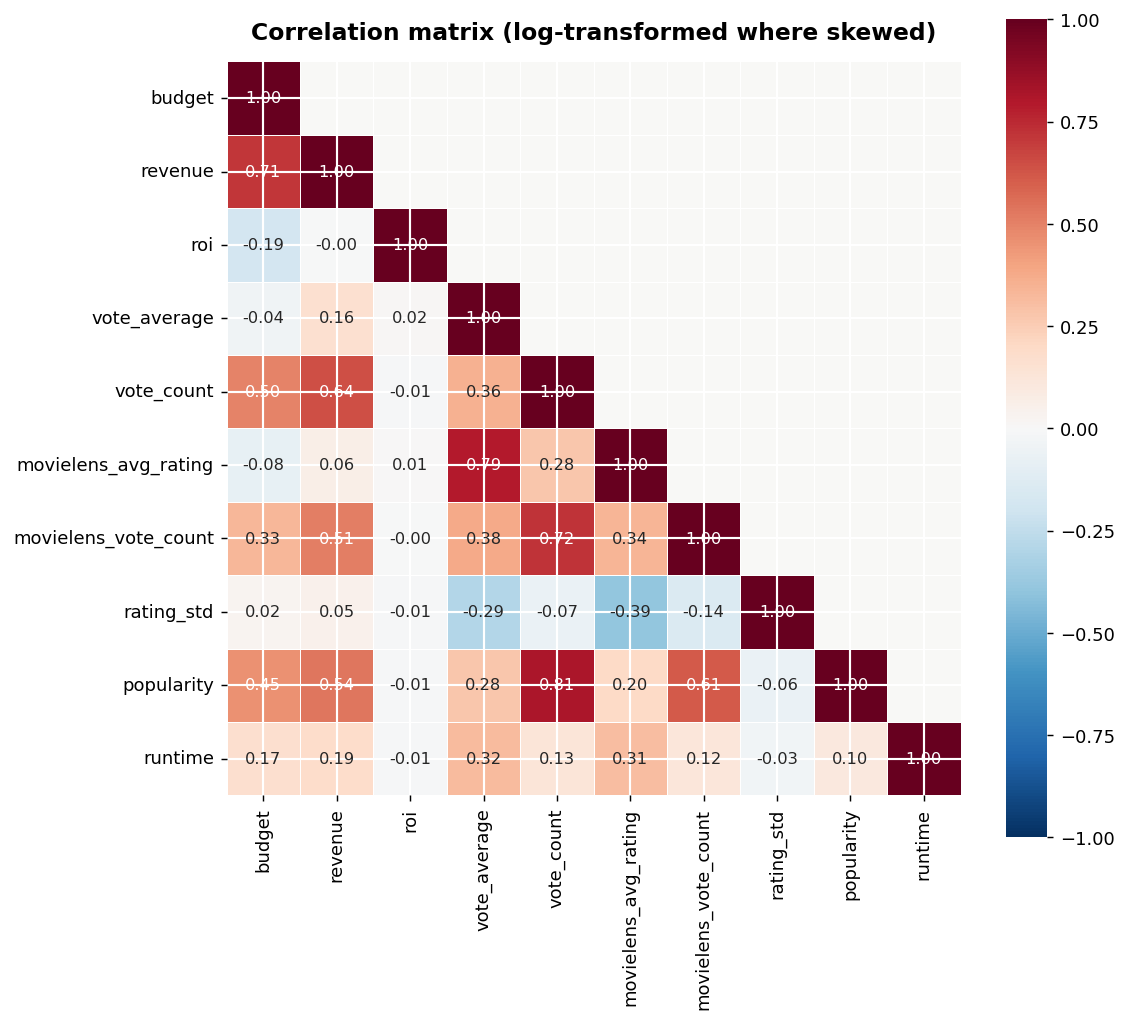

In [140]:
# ── 8a. Correlation matrix of key numeric variables ───────────────────────
corr_cols = [
    'budget', 'revenue', 'roi',
    'vote_average', 'vote_count',
    'movielens_avg_rating', 'movielens_vote_count',
    'rating_std', 'popularity', 'runtime'
]

corr_df = movies_financial[corr_cols].copy()
# log-transform skewed columns
for col in ['budget', 'revenue', 'vote_count', 'movielens_vote_count', 'popularity']:
    corr_df[col] = np.log10(corr_df[col].clip(lower=1))

corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax,
    mask=mask  # upper triangle only shown for readability → use mask=None for full
)
ax.set_title('Correlation matrix (log-transformed where skewed)', pad=12)
plt.tight_layout()
savefig('18_correlation_matrix')

In [141]:
# ── 8b. Summary statistics table ─────────────────────────────────────────
summary_cols = [
    'budget', 'revenue', 'roi',
    'vote_average', 'movielens_avg_rating', 'rating_std',
    'popularity', 'runtime'
]
summary = movies_financial[summary_cols].describe().T[['count', 'mean', '50%', 'std', 'min', 'max']]
summary.columns = ['n', 'mean', 'median', 'std', 'min', 'max']
summary = summary.round(2)
print(summary)

                           n         mean       median           std  min  \
budget                5417.0  31016092.28  17000000.00  4.005737e+07  1.0   
revenue               5417.0  89879361.84  29918745.00  1.656886e+08  1.0   
roi                   5417.0      5528.92         2.05  2.161352e+05  0.0   
vote_average          5417.0         6.27         6.30  9.300000e-01  0.0   
movielens_avg_rating  5413.0         3.20         3.25  5.300000e-01  0.5   
rating_std            5368.0         0.99         0.98  1.800000e-01  0.0   
popularity            5417.0         9.74         8.36  1.378000e+01  0.0   
runtime               5416.0       109.78       106.00  2.201000e+01  0.0   

                               max  
budget                3.800000e+08  
revenue               2.787965e+09  
roi                   1.239638e+07  
vote_average          9.100000e+00  
movielens_avg_rating  5.000000e+00  
rating_std            2.830000e+00  
popularity            5.474900e+02  
runtime   